# ARTI403 – Image Processing – Lab 1

**Student Name:** Faisal Abdullah Alshehri  
**Student ID:** 2240001737

## Setup and import the required libraries

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

images_dir = Path("images")
cameraman_path = images_dir / "cameraman.tif"
lena_path = images_dir / "lena_gray_256.tif"

print("Libraries imported and image paths are ready.")


Libraries imported and image paths are ready.


## Task 2(a): Loading and visualizing an image using OpenCV

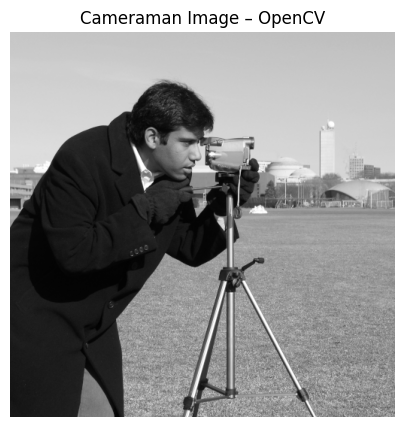

In [2]:
# cv2.imread loads the image as a NumPy array.
img = cv2.imread(str(cameraman_path), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f'Could not read {cameraman_path}')

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title('Cameraman Image – OpenCV')
plt.axis('off')
plt.show()

## Task 2(b): Loading and visualizing an image using PIL

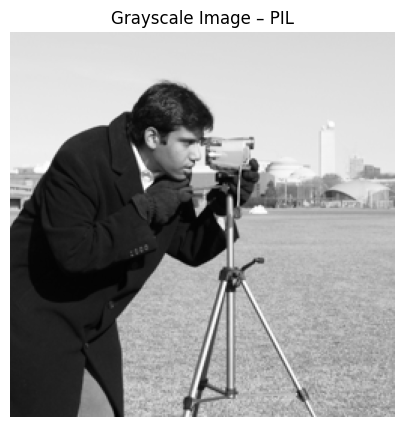

In [3]:
# Image.open loads the image as a PIL Image object.
img2 = Image.open(lena_path)

plt.figure(figsize=(5, 5))
plt.imshow(img2, cmap=cm.Greys_r)
plt.title('Grayscale Image – PIL')
plt.axis('off')
plt.show()

## Task 3: Image storing

In [4]:
# Save the OpenCV image.
opencv_saved = cv2.imwrite('new_image.jpg', img)

# Save the PIL image.
img2.save('new_image2.jpg')

print('OpenCV image saved:', opencv_saved)
print('PIL image saved:', Path('new_image2.jpg').exists())

OpenCV image saved: True
PIL image saved: True


## Task 4: Display images as arrays

In [5]:
# The image loaded with OpenCV is already a NumPy array.
print('OpenCV image shape:', img.shape)
print('OpenCV array data type:', img.dtype)
print('OpenCV image array:')
print(img)

OpenCV image shape: (512, 512)
OpenCV array data type: uint8
OpenCV image array:
[[200 200 200 ... 189 190 190]
 [200 199 199 ... 190 190 190]
 [199 199 199 ... 190 190 190]
 ...
 [ 25  25  27 ... 139 122 147]
 [ 25  25  26 ... 158 141 168]
 [ 25  25  27 ... 151 152 149]]


In [6]:
# Convert the PIL Image object to a NumPy array.
img_array = np.array(img2)

print('PIL image array shape:', img_array.shape)
print('PIL image array data type:', img_array.dtype)
print('PIL image array:')
print(img_array)

PIL image array shape: (256, 256)
PIL image array data type: uint8
PIL image array:
[[199 199 200 ... 190 190 190]
 [199 199 200 ... 190 190 190]
 [200 200 199 ... 191 191 191]
 ...
 [ 25  25  24 ... 136 143 118]
 [ 26  25  26 ... 147 154 144]
 [ 25  25  25 ... 146 146 151]]


## Assessment: NumPy operations on the image array

In [7]:
print('Minimum intensity:', np.min(img_array))
print('Maximum intensity:', np.max(img_array))
print('Mean intensity:', np.mean(img_array))
print('Standard deviation:', np.std(img_array))

Minimum intensity: 0
Maximum intensity: 255
Mean intensity: 129.06893920898438
Standard deviation: 73.04908779785245


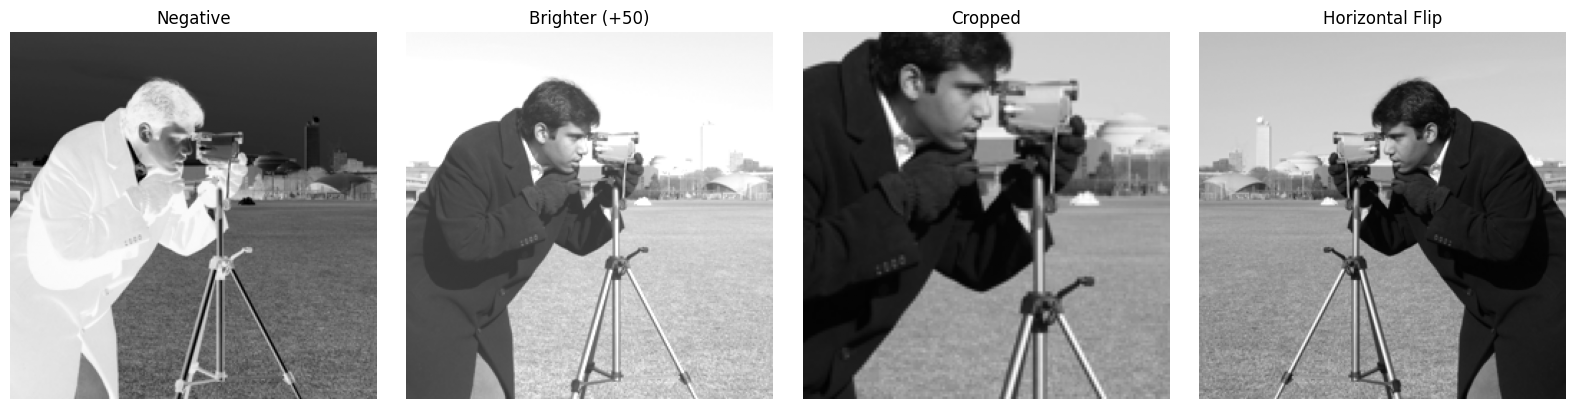

In [8]:
# Example array operations: negative, brighter image, crop, and horizontal flip.
negative_img = 255 - img_array
brighter_img = np.clip(img_array.astype(np.int16) + 50, 0, 255).astype(np.uint8)
cropped_img = img_array[50:200, 50:200]
flipped_img = np.fliplr(img_array)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
images = [negative_img, brighter_img, cropped_img, flipped_img]
titles = ['Negative', 'Brighter (+50)', 'Cropped', 'Horizontal Flip']

for ax, output_image, title in zip(axes, images, titles):
    ax.imshow(output_image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Conclusion
In this lab, images were loaded, displayed, and saved using OpenCV and PIL. The images were represented as NumPy arrays, and several operations were applied to their pixel intensity values.